                     Demanda  Temperatura  Feriado
Data                                              
2023-01-01 00:00:00  5450.38         16.9        1
2023-01-01 01:00:00  4900.18         20.7        1
2023-01-01 02:00:00  5555.96         32.8        1
2023-01-01 03:00:00  3679.67         18.0        1
2023-01-01 04:00:00  5437.41         24.9        1


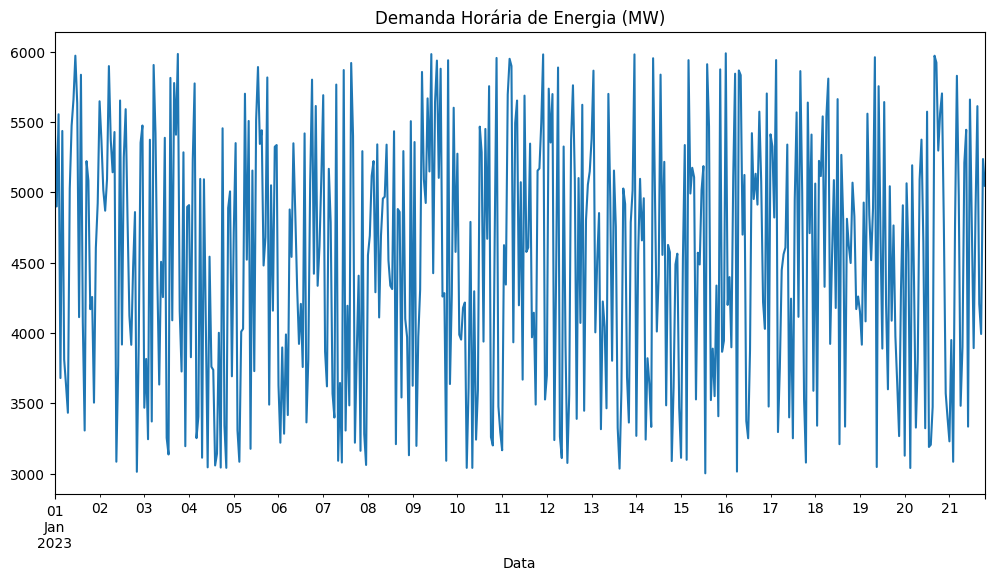

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar dados
data = pd.read_csv('dados_demanda.csv', parse_dates=['Data'], index_col='Data')
data = data.iloc[:, :-1]
print(data.head())

# Plotar série temporal
data['Demanda'].plot(figsize=(12, 6))
plt.title('Demanda Horária de Energia (MW)')
plt.show()

In [10]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Normalizar
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Criar sequências (janela de 1 semana = 168 horas, horizonte de 7 dias = 168 horas)
def create_sequences(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon, 0])  # Demanda está na coluna 0
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window_size=168, horizon=168)

In [27]:
data['time_idx'] = range(len(data))
data['id'] = 1

In [28]:
data['Feriado'] = data['Feriado'].map({1: 'yes', 0: 'no'})

In [29]:
data.head()

,Demanda,Temperatura,Feriado,time_idx,id
Data,,,,,
2023-01-01 00:00:00,5450.38,16.9,yes,0,1
2023-01-01 01:00:00,4900.18,20.7,yes,1,1
2023-01-01 02:00:00,5555.96,32.8,yes,2,1
2023-01-01 03:00:00,3679.67,18.0,yes,3,1
2023-01-01 04:00:00,5437.41,24.9,yes,4,1


In [34]:
import torch
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

# Criar dataset
dataset = TimeSeriesDataSet(
    data=data,
    time_idx="time_idx",  # Coluna de índice temporal
    target="Demanda",
    group_ids=["id"],  # Único grupo (série única)
    max_encoder_length=168,  # Janela de entrada (1 semana)
    max_prediction_length=168,  # Horizonte (1 semana)
    static_categoricals=["Feriado"],
    time_varying_known_reals=["Temperatura"],
    time_varying_unknown_reals=["Demanda"],
)

# Treinador
trainer = pl.Trainer(max_epochs=50)
tft = TemporalFusionTransformer.from_dataset(
    dataset,
    hidden_size=64,
    lstm_layers=2,
    attention_head_size=4,
    dropout=0.1,
    output_size=7,  # 7 quantis (P10, P20, ..., P90)
    loss=QuantileLoss(quantiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/felipe/Documents/ds/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/felipe/Documents/ds/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [ ]:
from torch.utils.data import random_split
from pytorch_forecasting.data import GroupNormalizer
from torch.utils.data import DataLoader

from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from torch.utils.data import DataLoader

# 1. Criar o dataset COMPLETO primeiro
dataset = TimeSeriesDataSet(
    data=data,
    time_idx="time_idx",
    target="Demanda",
    group_ids=["id"],
    max_encoder_length=168,
    max_prediction_length=24,
    target_normalizer=GroupNormalizer(),
    time_varying_known_reals=["Temperatura"],
    time_varying_unknown_reals=["Demanda"],
    static_categoricals=["Feriado"]
)

# 2. Filtrar os dados ANTES de criar sub-datasets
train_mask = data["time_idx"] < data["time_idx"].max() * 0.8  # 80% treino
val_mask = ~train_mask  # 20% validação

# 3. Criar datasets separados
train_dataset = TimeSeriesDataSet(
    data[train_mask],
    **dataset.get_parameters()  # Herda TODAS configurações
)

from pytorch_forecasting.utils import create_validation_index

val_idx = create_validation_index(
    data,
    validation_split=0.2,
    max_encoder_length=dataset.max_encoder_length,
    max_prediction_length=dataset.max_prediction_length
)

val_dataset = TimeSeriesDataSet(
    data.iloc[val_idx],
    **dataset.get_parameters()
)

# val_dataset = TimeSeriesDataSet(
#     data[val_mask],
#     **dataset.get_parameters()
# )

# # 4. Criar DataLoaders CORRETAMENTE
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=32,
#     shuffle=True,
#     num_workers=4
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=128,
#     shuffle=False,
#     num_workers=4
# )

ImportError: cannot import name 'create_validation_index' from 'pytorch_forecasting.utils' (/Users/felipe/Documents/ds/lib/python3.13/site-packages/pytorch_forecasting/utils/__init__.py)

In [ ]:
trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)